In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import datetime
import itertools
import matplotlib.dates as mdates
import pandas as pd
import gc
import tensorflow as tf

I0000 00:00:1788849918.101078  110570 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
import gc
import tensorflow as tf

tf.keras.backend.clear_session()
gc.collect()

keras.backend.clear_session()

0

In [3]:
import os

# Data path from AGENTS.md
data_folder = "/home/haseebumer/content/data/extracted/"

# !change model name for different models!
model_name = "CNN_LSTM_nowcast_2017_2019_data"
output_folder = os.path.join("model_output", model_name)

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# File paths for extracted datasets
trainval_images_path = os.path.join(data_folder, "trainval_images_log.npy")
trainval_pv_path = os.path.join(data_folder, "trainval_pv_log.npy")
test_images_path = os.path.join(data_folder, "test_images_log.npy")
test_pv_path = os.path.join(data_folder, "test_pv_log.npy")

times_trainval_path = os.path.join(data_folder, "times_trainval.npy")
times_test_path = os.path.join(data_folder, "times_test.npy")

print("data_folder:", data_folder)
print("output_folder:", output_folder)
print("trainval_images:", trainval_images_path)
print("trainval_pv:", trainval_pv_path)

data_folder: /home/haseebumer/content/data/extracted/
output_folder: model_output/CNN_LSTM_nowcast_2017_2019_data
trainval_images: /home/haseebumer/content/data/extracted/trainval_images_log.npy
trainval_pv: /home/haseebumer/content/data/extracted/trainval_pv_log.npy


## Data Loading & Training


In [4]:
# Model & Training parameters
SEQ_LEN = 16  # Number of historical time steps (lags) used as input sequence
# 0 for nowcast (predicting t from t-SEQ_LEN...t-1), or >0 for future horizon
FORECAST_HORIZON = 0
NUM_FOLDS = 10  # 10-fold cross validation
NUM_EPOCHS = 200  # Max epochs (EarlyStopping will halt earlier)
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
PATIENCE = 10  # Early stopping patience

In [5]:
# Memory-map large image files to prevent Colab RAM overflow (Best Practice)
trainval_images = np.load(trainval_images_path, mmap_mode="r")
test_images = np.load(test_images_path, mmap_mode="r")

trainval_pv = np.load(trainval_pv_path).astype(np.float32)
test_pv = np.load(test_pv_path).astype(np.float32)

times_trainval = np.load(times_trainval_path, allow_pickle=True)
times_test = np.load(times_test_path, allow_pickle=True)

print(
    f"trainval_images shape: {trainval_images.shape} | dtype: {trainval_images.dtype}"
)
print(f"test_images shape:     {test_images.shape} | dtype: {test_images.dtype}")
print(f"trainval_pv shape:     {trainval_pv.shape} | times: {times_trainval.shape}")
print(f"test_pv shape:         {test_pv.shape} | times: {times_test.shape}")

trainval_images shape: (349372, 64, 64, 3) | dtype: uint8
test_images shape:     (14003, 64, 64, 3) | dtype: uint8
trainval_pv shape:     (349372,) | times: (349372,)
test_pv shape:         (14003,) | times: (14003,)


In [6]:
def create_day_aware_sequences(
    pv_array, times_array, images_array=None, seq_len=16, horizon=0
):
    """
    Constructs (X, y, sequence_dates, sequence_times) sequences
    ensuring that no sequence crosses overnight boundaries or distinct dates.
    To prevent RAM overflow and kernel crashes, images are not duplicated into RAM;
    instead, integer indices are tracked to stream images on-demand from disk/mmap.
    """

    dates = np.array(
        [
            (
                t.date()
                if isinstance(t, (datetime.datetime, datetime.date))
                else pd.to_datetime(t).date()
            )
            for t in times_array
        ]
    )

    unique_dates = np.unique(dates)

    X_pv_list, y_list = [], []
    valid_dates_list = []
    valid_times_list = []
    img_indices_list = [] if images_array is not None else None

    for d in unique_dates:
        day_indices = np.where(dates == d)[0]
        num_day_points = len(day_indices)

        # Minimum required points for sequence + target
        if num_day_points <= seq_len + horizon:
            continue

        day_pv = pv_array[day_indices]
        day_times = times_array[day_indices]

        for i in range(seq_len, num_day_points - horizon):
            seq_x = day_pv[i - seq_len : i]

            target_idx = i + horizon
            seq_y = day_pv[target_idx]

            X_pv_list.append(seq_x)
            y_list.append(seq_y)
            valid_dates_list.append(d)
            valid_times_list.append(day_times[target_idx])

            if images_array is not None:
                # Concurrent sky camera image index for nowcast prediction at target_idx
                img_indices_list.append(day_indices[target_idx])

    X_pv = np.expand_dims(
        np.array(X_pv_list, dtype=np.float32), axis=-1
    )  # Shape: (N, seq_len, 1)

    y = np.array(y_list, dtype=np.float32)  # Shape: (N,)

    valid_dates = np.array(valid_dates_list)
    valid_times = np.array(valid_times_list)

    if images_array is not None:
        img_indices = np.array(img_indices_list, dtype=np.int32)
        # Return multimodal bundle: (mmap_images, pv_sequences, image_indices)
        return (images_array, X_pv, img_indices), y, valid_dates, valid_times
    else:
        return X_pv, y, valid_dates, valid_times


X_trainval, y_trainval, dates_trainval_seq, times_trainval_seq = (
    create_day_aware_sequences(
        trainval_pv,
        times_trainval,
        images_array=trainval_images,
        seq_len=SEQ_LEN,
        horizon=FORECAST_HORIZON,
    )
)

X_test, y_test, dates_test_seq, times_test_seq = create_day_aware_sequences(
    test_pv,
    times_test,
    images_array=test_images,
    seq_len=SEQ_LEN,
    horizon=FORECAST_HORIZON,
)

print(
    f"X_trainval sequences: {len(y_trainval):,} | "
    f"PV shape: {X_trainval[1].shape} | "
    f"Images storage: {X_trainval[0].shape} (mmap on-demand)"
)
print(
    f"X_test sequences:     {len(y_test):,} | "
    f"PV shape: {X_test[1].shape} | "
    f"Images storage: {X_test[0].shape} (mmap on-demand)"
)

X_trainval sequences: 341,420 | PV shape: (341420, 16, 1) | Images storage: (349372, 64, 64, 3) (mmap on-demand)
X_test sequences:     13,683 | PV shape: (13683, 16, 1) | Images storage: (14003, 64, 64, 3) (mmap on-demand)


In [7]:
def shuffle_unique_dates(dates_array, seed=1):
    """
    Shuffles the unique CALENDAR DATES (not sample indices).
    Fold boundaries will be cut on this array, so folds are day-based.
    """
    unique_dates = np.unique(dates_array)
    rng = np.random.RandomState(seed)
    rng.shuffle(unique_dates)
    return unique_dates


def cv_split_indices(dates_array_full, shuffled_unique_dates, fold_index, num_folds=10):
    """
    Splits by whole days: the fold_index-th slice of shuffled_unique_dates
    becomes the validation dates. Every sample whose date falls in that
    slice goes to validation; everything else goes to training.
    No calendar day is ever split across train and validation.
    """
    num_days = len(shuffled_unique_dates)
    val_start = int(fold_index / num_folds * num_days)
    val_end = int((fold_index + 1) / num_folds * num_days)

    val_dates = set(shuffled_unique_dates[val_start:val_end])

    val_mask = np.isin(dates_array_full, list(val_dates))
    train_mask = ~val_mask

    all_indices = np.arange(len(dates_array_full))
    train_idx = all_indices[train_mask]
    val_idx = all_indices[val_mask]

    rng = np.random.RandomState(fold_index)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def build_tf_dataset(X, y, indices, batch_size=256, is_training=True):
    """
    Builds an optimized streaming tf.data.Dataset pipeline.
    Streams image batches on-demand directly from memory-mapped disk storage,
    preventing RAM exhaustion (OOM) and kernel crashes.
    Uses prefetching and AUTOTUNE for maximum GPU training throughput.
    """
    if isinstance(X, (tuple, list)) and len(X) == 3:
        images_mmap, X_pv, img_indices = X
        sub_indices = np.array(indices)
        num_samples = len(sub_indices)
        num_batches = int(np.ceil(num_samples / batch_size))

        def generator():
            curr_idx = sub_indices.copy()
            if is_training:
                np.random.shuffle(curr_idx)
            for start in range(0, num_samples, batch_size):
                b_idx = curr_idx[start : start + batch_size]
                b_img_idx = img_indices[b_idx]
                # Slice only the current batch of images from mmap storage (~3MB RAM)
                b_img = images_mmap[b_img_idx]
                b_pv = X_pv[b_idx]
                b_y = y[b_idx]
                yield (b_img, b_pv), b_y

        output_signature = (
            (
                tf.TensorSpec(shape=(None, 64, 64, 3), dtype=tf.uint8),
                tf.TensorSpec(
                    shape=(None, X_pv.shape[1], X_pv.shape[2]), dtype=tf.float32
                ),
            ),
            tf.TensorSpec(shape=(None,), dtype=tf.float32),
        )

        ds = tf.data.Dataset.from_generator(
            generator, output_signature=output_signature
        )
        ds = ds.apply(tf.data.experimental.assert_cardinality(num_batches))
        return ds.prefetch(tf.data.AUTOTUNE)
    else:
        X_sub = X[indices]
        y_sub = y[indices]

        ds = tf.data.Dataset.from_tensor_slices((X_sub, y_sub))

        if is_training:
            ds = ds.shuffle(buffer_size=min(len(indices), 10000), seed=42)

        ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

        return ds

In [8]:
keras.backend.clear_session()

In [9]:
def build_cnn_feature_extractor(
    input_shape=(64, 64, 3),
    filters=(32, 64, 128),
    feature_dim=64,
    name="cnn_feature_extractor",
):
    """
    Builds a 2D CNN backbone to extract visual features from sky camera images.
    Uses tf.keras.layers.Rescaling(1.0 / 255.0) to normalize uint8 images on-GPU.
    """
    img_in = keras.Input(shape=input_shape, name="cnn_image_in")
    # Best practice: scale uint8 [0, 255] images to [0.0, 1.0] on-GPU
    x = keras.layers.Rescaling(1.0 / 255.0, name="rescaling")(img_in)
    for i, f in enumerate(filters):
        x = keras.layers.Conv2D(
            filters=f,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            name=f"conv_{i+1}",
        )(x)
        x = keras.layers.BatchNormalization(name=f"bn_{i+1}")(x)
        x = keras.layers.MaxPooling2D(pool_size=(2, 2), name=f"pool_{i+1}")(x)

    # Spatial pooling into a dense feature vector
    x = keras.layers.GlobalAveragePooling2D(name="gap")(x)
    x = keras.layers.Dense(feature_dim, activation="relu", name="cnn_feature_proj")(x)

    return keras.Model(inputs=img_in, outputs=x, name=name)


def build_cnn_lstm_model(
    seq_len=16,
    num_features=1,
    image_shape=(64, 64, 3),
    cnn_filters=(32, 64, 128),
    cnn_feature_dim=64,
    lstm_units=(64, 64),
    dense_units=128,
):
    """
    Builds a Multimodal CNN + LSTM Fusion model:
    1. Visual features from sky camera images are extracted by a 2D CNN backbone.
    2. Image features are concatenated with the corresponding time series PV data.
    3. The combined representation is passed to LSTM layers for temporal sequence modeling.
    4. A Dense regression head outputs the solar PV nowcast prediction.
    """
    # 1. Multimodal Inputs
    is_image_sequence = len(image_shape) == 4  # e.g., (seq_len, H, W, C)

    if is_image_sequence:
        image_input = keras.Input(shape=image_shape, name="image_sequence_input")
        single_img_shape = image_shape[1:]
    else:
        image_input = keras.Input(shape=image_shape, name="image_input")
        single_img_shape = image_shape

    pv_input = keras.Input(shape=(seq_len, num_features), name="pv_sequence_input")

    # 2. Extract image features via CNN
    cnn_extractor = build_cnn_feature_extractor(
        input_shape=single_img_shape,
        filters=cnn_filters,
        feature_dim=cnn_feature_dim,
        name="cnn_backbone",
    )

    if is_image_sequence:
        img_features_seq = keras.layers.TimeDistributed(
            cnn_extractor, name="time_distributed_cnn"
        )(image_input)
    else:
        img_features = cnn_extractor(image_input)
        # Repeat single image features across time steps to align with the PV sequence
        img_features_seq = keras.layers.RepeatVector(
            seq_len, name="repeat_image_features"
        )(img_features)

    # 3. Concatenate image features with corresponding time series PV data
    fused = keras.layers.Concatenate(axis=-1, name="fusion_concat")(
        [img_features_seq, pv_input]
    )

    # 4. Pass fused sequence to LSTM
    x = fused
    if isinstance(lstm_units, (list, tuple)):
        for i, units in enumerate(lstm_units):
            is_last = i == len(lstm_units) - 1
            x = keras.layers.LSTM(
                units=units,
                return_sequences=not is_last,
                name=f"lstm_{i+1}",
            )(x)
    else:
        x = keras.layers.LSTM(
            units=lstm_units,
            return_sequences=False,
            name="lstm_1",
        )(x)

    # 5. Dense head for nowcast prediction
    x = keras.layers.Dense(dense_units, activation="relu", name="dense_1")(x)

    outputs = keras.layers.Dense(units=1, activation="linear", name="pv_prediction")(x)

    model = keras.Model(
        inputs=[image_input, pv_input],
        outputs=outputs,
        name="CNN_LSTM_Solar_Forecast",
    )

    return model


sample_model = build_cnn_lstm_model(
    seq_len=SEQ_LEN,
    num_features=1,
    image_shape=(64, 64, 3),
)

sample_model.summary()

I0000 00:00:1788849943.950604  110570 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8101 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:23:00.0, compute capability: 8.6
I0000 00:00:1788849943.951953  110570 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 7755 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:2d:00.0, compute capability: 8.6


Model: "CNN_LSTM_Solar_Forecast"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_backbone        │ (None, 64)        │    102,400 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_image_featu… │ (None, 16, 64)    │          0 │ cnn_backbone[0][… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pv_sequence_input   │ (None, 16, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 16, 65)    │          0 │ repeat_image_fea… │
│ (Concatenate)       │                   │            │ pv_sequence_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 16, 64)    │     33,280 │ fusion_concat[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     33,024 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      8,320 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pv_prediction       │ (None, 1)         │        129 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 177,153 (692.00 KB)

 Trainable params: 176,705 (690.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
shuffled_unique_dates = shuffle_unique_dates(dates_trainval_seq, seed=1)

# --- Resume support: load existing history if this cell was run before ---
history_paths = {
    "train_loss": os.path.join(output_folder, "train_loss_hist.npy"),
    "val_loss": os.path.join(output_folder, "val_loss_hist.npy"),
    "train_mae": os.path.join(output_folder, "train_mae_hist.npy"),
    "val_mae": os.path.join(output_folder, "val_mae_hist.npy"),
}

if all(os.path.exists(p) for p in history_paths.values()):
    train_loss_hist = list(np.load(history_paths["train_loss"], allow_pickle=True))
    val_loss_hist = list(np.load(history_paths["val_loss"], allow_pickle=True))
    train_mae_hist = list(np.load(history_paths["train_mae"], allow_pickle=True))
    val_mae_hist = list(np.load(history_paths["val_mae"], allow_pickle=True))
    print(
        f"Resuming: found existing history for {len(train_loss_hist)} completed fold(s)."
    )
else:
    train_loss_hist = []
    val_loss_hist = []
    train_mae_hist = []
    val_mae_hist = []

# A fold counts as "done" only if BOTH its checkpoint exists AND its history was
# already recorded above (checkpoint alone isn't proof the fold finished/saved).
start_fold = len(train_loss_hist)

if start_fold >= NUM_FOLDS:
    print(f"All {NUM_FOLDS} folds already completed. Nothing to train.")

for fold in range(start_fold, NUM_FOLDS):

    print(f" Repetition / Fold {fold + 1} of {NUM_FOLDS} ")

    keras.backend.clear_session()

    model = build_cnn_lstm_model(seq_len=SEQ_LEN, num_features=1)

    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

    save_directory = os.path.join(output_folder, f"repetition_{fold + 1}")

    os.makedirs(save_directory, exist_ok=True)

    checkpoint_path = os.path.join(
        save_directory, f"best_model_repetition_{fold + 1}.h5"
    )

    # TensorBoard

    tensorboard_log_dir = os.path.join(
        output_folder, "tensorboard_logs", f"repetition_{fold + 1}"
    )

    os.makedirs(tensorboard_log_dir, exist_ok=True)

    # Splits & Datasets (day-level split — no day appears in both train and val)
    idx_train, idx_val = cv_split_indices(
        dates_trainval_seq, shuffled_unique_dates, fold, NUM_FOLDS
    )

    ds_train = build_tf_dataset(
        X_trainval, y_trainval, idx_train, batch_size=BATCH_SIZE, is_training=True
    )

    ds_val = build_tf_dataset(
        X_trainval, y_trainval, idx_val, batch_size=BATCH_SIZE, is_training=False
    )

    # Callbacks
    earlystop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1,
    )

    checkpoint = keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor="val_loss", mode="min", save_best_only=True, verbose=1
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )

    # TensorBoard Callback

    tensorboard = keras.callbacks.TensorBoard(
        log_dir=tensorboard_log_dir,
        histogram_freq=1,
        write_graph=True,
        update_freq="epoch",
    )

    # Training
    history = model.fit(
        ds_train,
        epochs=NUM_EPOCHS,
        validation_data=ds_val,
        callbacks=[earlystop, checkpoint, reduce_lr, tensorboard],
        verbose=1,
    )

    # Store training history
    train_loss_hist.append(history.history["loss"])
    val_loss_hist.append(history.history["val_loss"])
    train_mae_hist.append(history.history["mae"])
    val_mae_hist.append(history.history["val_mae"])

    # Save history arrays (checkpointed after EVERY fold, so a crash mid-run
    # only loses the in-progress fold, not previously completed ones)
    np.save(history_paths["train_loss"], np.array(train_loss_hist, dtype=object))
    np.save(history_paths["val_loss"], np.array(val_loss_hist, dtype=object))
    np.save(history_paths["train_mae"], np.array(train_mae_hist, dtype=object))
    np.save(history_paths["val_mae"], np.array(val_mae_hist, dtype=object))

    print(f"Fold {fold + 1} complete and saved.")

Resuming: found existing history for 9 completed fold(s).
 Repetition / Fold 10 of 10 


/home/haseebumer/skippd-solar-forecasting/aienv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/200


I0000 00:00:1788849954.791862  110570 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1788849956.847795  110748 cuda_dnn.cc:461] Loaded cuDNN version 92400


1196/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 4.0344 - mae: 0.6351
Epoch 1: val_loss improved from None to 1.18013, saving model to model_output/CNN_LSTM_nowcast_2017_2019_data/repetition_10/best_model_repetition_10.h5


...


Epoch 2: finished saving model to model_output/CNN_LSTM_nowcast_2017_2019_data/repetition_10/best_model_repetition_10.h5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - loss: 0.7660 - mae: 0.3328 - val_loss: 0.7217 - val_mae: 0.2713 - learning_rate: 0.0010
Epoch 3/200
1195/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.7626 - mae: 0.3355
Epoch 3: val_loss did not improve from 0.72174
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - loss: 0.7624 - mae: 0.3354 - val_loss: 0.7510 - val_mae: 0.3686 - learning_rate: 0.0010
Epoch 4/200
1195/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.7483 - mae: 0.3203
Epoch 4: val_loss did not improve from 0.72174
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - loss: 0.7484 - mae: 0.3203 - val_loss: 0.8023 - val_mae: 0.4305 - learning_rate: 0.0010
Epoch 5/200
1195/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.7414 - mae: 0.3203
Epoch 5: val_loss did not improve from 0.72174

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 8: finished saving model to model_output/CNN_LSTM_nowcast_2017_2019_data/repetition_10/best_model_repetition_10.h5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - loss: 0.7047 - mae: 0.2951 - val_loss: 0.6932 - val_mae: 0.2592 - learning_rate: 5.0000e-04
Epoch 9/200
1195/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.6939 - mae: 0.2848
Epoch 9: val_loss improved from 0.69319 to 0.67886, saving model to model_output/CNN_LSTM_nowcast_2017_2019_data/repetition_10/best_model_repetition_10.h5



Epoch 9: finished saving model to model_output/CNN_LSTM_nowcast_2017_2019_data/repetition_10/best_model_repetition_10.h5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - loss: 0.6938 - mae: 0.2848 - val_loss: 0.6789 - val_mae: 0.2687 - learning_rate: 5.0000e-04
Epoch 10/200
1195/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6930 - mae: 0.2917
Epoch 10: val_loss did not improve from 0.67886
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - loss: 0.6928 - mae: 0.2917 - val_loss: 0.7759 - val_mae: 0.3628 - learning_rate: 5.0000e-04
Epoch 11/200
1195/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6817 - mae: 0.2828
Epoch 11: val_loss did not improve from 0.67886
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - loss: 0.6818 - mae: 0.2828 - val_loss: 0.7301 - val_mae: 0.2433 - learning_rate: 5.0000e-04
Epoch 12/200
1195/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6765 - mae: 0.2830
Epoch 12: val_loss improved from 0.67886 to 0.67562, saving model to model_output/CNN_LSTM_nowcast_2017_201


Epoch 12: finished saving model to model_output/CNN_LSTM_nowcast_2017_2019_data/repetition_10/best_model_repetition_10.h5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - loss: 0.6763 - mae: 0.2830 - val_loss: 0.6756 - val_mae: 0.2300 - learning_rate: 5.0000e-04
Epoch 13/200
1195/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6678 - mae: 0.2808
Epoch 13: val_loss did not improve from 0.67562
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - loss: 0.6692 - mae: 0.2809 - val_loss: 0.7079 - val_mae: 0.2902 - learning_rate: 5.0000e-04
Epoch 14/200
1195/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6594 - mae: 0.2806
Epoch 14: val_loss did not improve from 0.67562
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - loss: 0.6596 - mae: 0.2806 - val_loss: 0.6967 - val_mae: 0.2732 - learning_rate: 5.0000e-04
Epoch 15/200
1195/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6534 - mae: 0.2808
Epoch 15: val_loss did not improve from 0.67562

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0


Epoch 16: finished saving model to model_output/CNN_LSTM_nowcast_2017_2019_data/repetition_10/best_model_repetition_10.h5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - loss: 0.6217 - mae: 0.2569 - val_loss: 0.6743 - val_mae: 0.2421 - learning_rate: 2.5000e-04
Epoch 17/200
1195/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6066 - mae: 0.2563
Epoch 17: val_loss did not improve from 0.67433
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - loss: 0.6066 - mae: 0.2563 - val_loss: 0.7536 - val_mae: 0.3228 - learning_rate: 2.5000e-04
Epoch 18/200
1195/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.5958 - mae: 0.2557
Epoch 18: val_loss did not improve from 0.67433
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - loss: 0.5957 - mae: 0.2557 - val_loss: 0.7141 - val_mae: 0.2653 - learning_rate: 2.5000e-04
Epoch 19/200
1195/1196 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.5833 - mae: 0.2527
Epoch 19: val_loss did not improve from 0.67433

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0

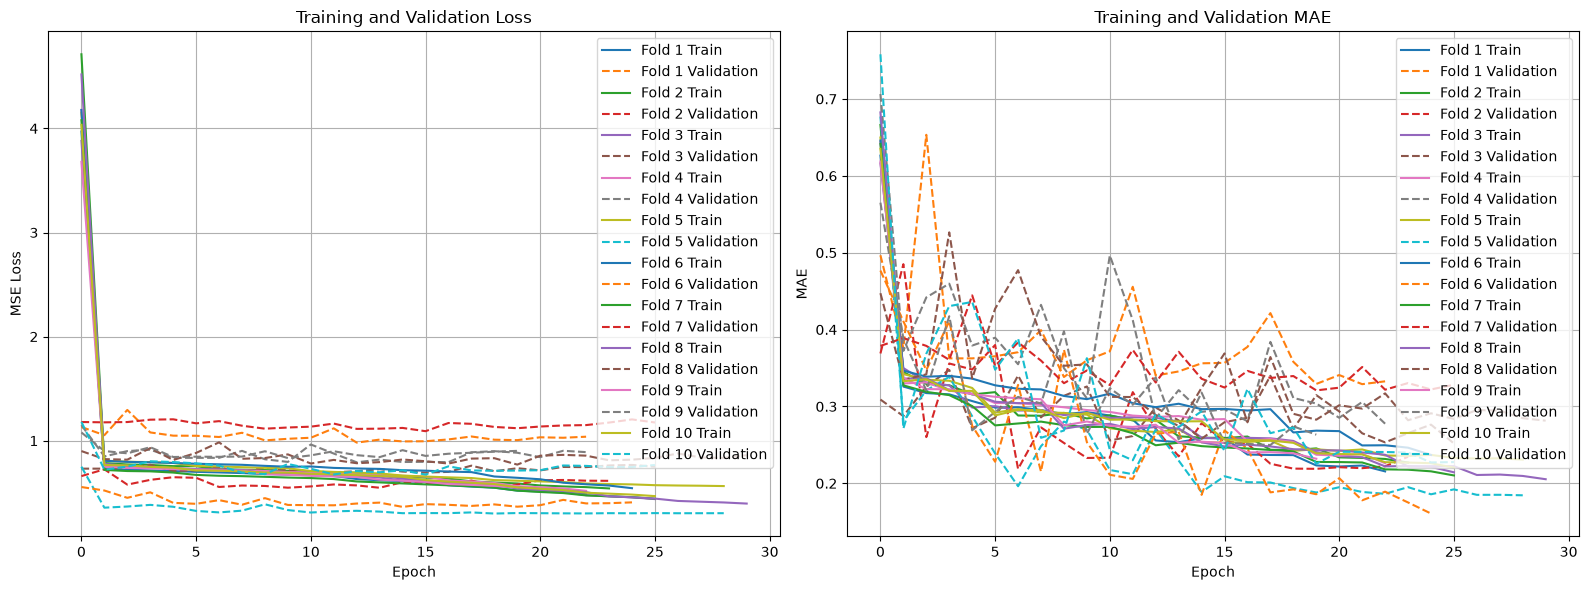

In [11]:
fig, axarr = plt.subplots(1, 2, figsize=(16, 6))


# TRAINING & VALIDATION LOSS

for fold in range(NUM_FOLDS):
    axarr[0].plot(train_loss_hist[fold], label=f"Fold {fold + 1} Train")

    axarr[0].plot(
        val_loss_hist[fold], linestyle="--", label=f"Fold {fold + 1} Validation"
    )

axarr[0].set_xlabel("Epoch")
axarr[0].set_ylabel("MSE Loss")
axarr[0].set_title("Training and Validation Loss")
axarr[0].legend()
axarr[0].grid(True)


# TRAINING & VALIDATION MAE

for fold in range(NUM_FOLDS):
    axarr[1].plot(train_mae_hist[fold], label=f"Fold {fold + 1} Train")

    axarr[1].plot(
        val_mae_hist[fold], linestyle="--", label=f"Fold {fold + 1} Validation"
    )

axarr[1].set_xlabel("Epoch")
axarr[1].set_ylabel("MAE")
axarr[1].set_title("Training and Validation MAE")
axarr[1].legend()
axarr[1].grid(True)


plt.tight_layout()
plt.show()

In [12]:
best_train_loss_mse = np.zeros(NUM_FOLDS)
best_val_loss_mse = np.zeros(NUM_FOLDS)

for i in range(NUM_FOLDS):
    best_val_loss_mse[i] = np.min(val_loss_hist[i])

    idx = np.argmin(val_loss_hist[i])
    best_train_loss_mse[i] = train_loss_hist[i][idx]

    print(
        f"Model {i + 1:02d} | "
        f"Train RMSE: {np.sqrt(best_train_loss_mse[i]):.3f} kW | "
        f"Val RMSE: {np.sqrt(best_val_loss_mse[i]):.3f} kW"
    )

print(f"Mean Train RMSE: " f"{np.mean(np.sqrt(best_train_loss_mse)):.3f} kW")
print(f"Mean Validation RMSE: " f"{np.mean(np.sqrt(best_val_loss_mse)):.3f} kW")

Model 01 | Train RMSE: 0.795 kW | Val RMSE: 0.991 kW
Model 02 | Train RMSE: 0.815 kW | Val RMSE: 0.740 kW
Model 03 | Train RMSE: 0.787 kW | Val RMSE: 0.833 kW
Model 04 | Train RMSE: 0.824 kW | Val RMSE: 0.890 kW
Model 05 | Train RMSE: 0.788 kW | Val RMSE: 0.548 kW
Model 06 | Train RMSE: 0.846 kW | Val RMSE: 0.603 kW
Model 07 | Train RMSE: 0.762 kW | Val RMSE: 1.045 kW
Model 08 | Train RMSE: 0.743 kW | Val RMSE: 0.878 kW
Model 09 | Train RMSE: 0.820 kW | Val RMSE: 0.913 kW
Model 10 | Train RMSE: 0.788 kW | Val RMSE: 0.821 kW
Mean Train RMSE: 0.797 kW
Mean Validation RMSE: 0.826 kW


In [13]:
predictions = np.zeros((NUM_FOLDS, len(y_test)), dtype=np.float32)

# Build streaming test dataset (batch_size=512 for fast evaluation)
ds_test = build_tf_dataset(
    X_test, y_test, np.arange(len(y_test)), batch_size=512, is_training=False
)

for fold in range(NUM_FOLDS):
    checkpoint_path = os.path.join(
        output_folder, f"repetition_{fold + 1}", f"best_model_repetition_{fold + 1}.h5"
    )

    print(f"Loading fold {fold + 1} model from: {checkpoint_path}")

    fold_model = build_cnn_lstm_model(
        seq_len=SEQ_LEN,
        num_features=1,
        image_shape=(64, 64, 3),
    )

    fold_model.load_weights(checkpoint_path)

    pred = fold_model.predict(ds_test, verbose=0)

    predictions[fold] = np.squeeze(pred)

# Save individual fold predictions
np.save(os.path.join(output_folder, "test_predictions_all_folds.npy"), predictions)

# Ensemble average
ensemble_predictions = np.mean(predictions, axis=0)

np.save(
    os.path.join(output_folder, "test_predictions_ensemble.npy"), ensemble_predictions
)

Loading fold 1 model from: model_output/CNN_LSTM_nowcast_2017_2019_data/repetition_1/best_model_repetition_1.h5
Loading fold 2 model from: model_output/CNN_LSTM_nowcast_2017_2019_data/repetition_2/best_model_repetition_2.h5
Loading fold 3 model from: model_output/CNN_LSTM_nowcast_2017_2019_data/repetition_3/best_model_repetition_3.h5
Loading fold 4 model from: model_output/CNN_LSTM_nowcast_2017_2019_data/repetition_4/best_model_repetition_4.h5
Loading fold 5 model from: model_output/CNN_LSTM_nowcast_2017_2019_data/repetition_5/best_model_repetition_5.h5
Loading fold 6 model from: model_output/CNN_LSTM_nowcast_2017_2019_data/repetition_6/best_model_repetition_6.h5
Loading fold 7 model from: model_output/CNN_LSTM_nowcast_2017_2019_data/repetition_7/best_model_repetition_7.h5
Loading fold 8 model from: model_output/CNN_LSTM_nowcast_2017_2019_data/repetition_8/best_model_repetition_8.h5
Loading fold 9 model from: model_output/CNN_LSTM_nowcast_2017_2019_data/repetition_9/best_model_repetiti

COMPLETE TEST SET NOWCAST RESULTS
Total Test Sequences: 13,683
Overall Test RMSE:    1.332 kW
Overall Test MAE:     0.456 kW


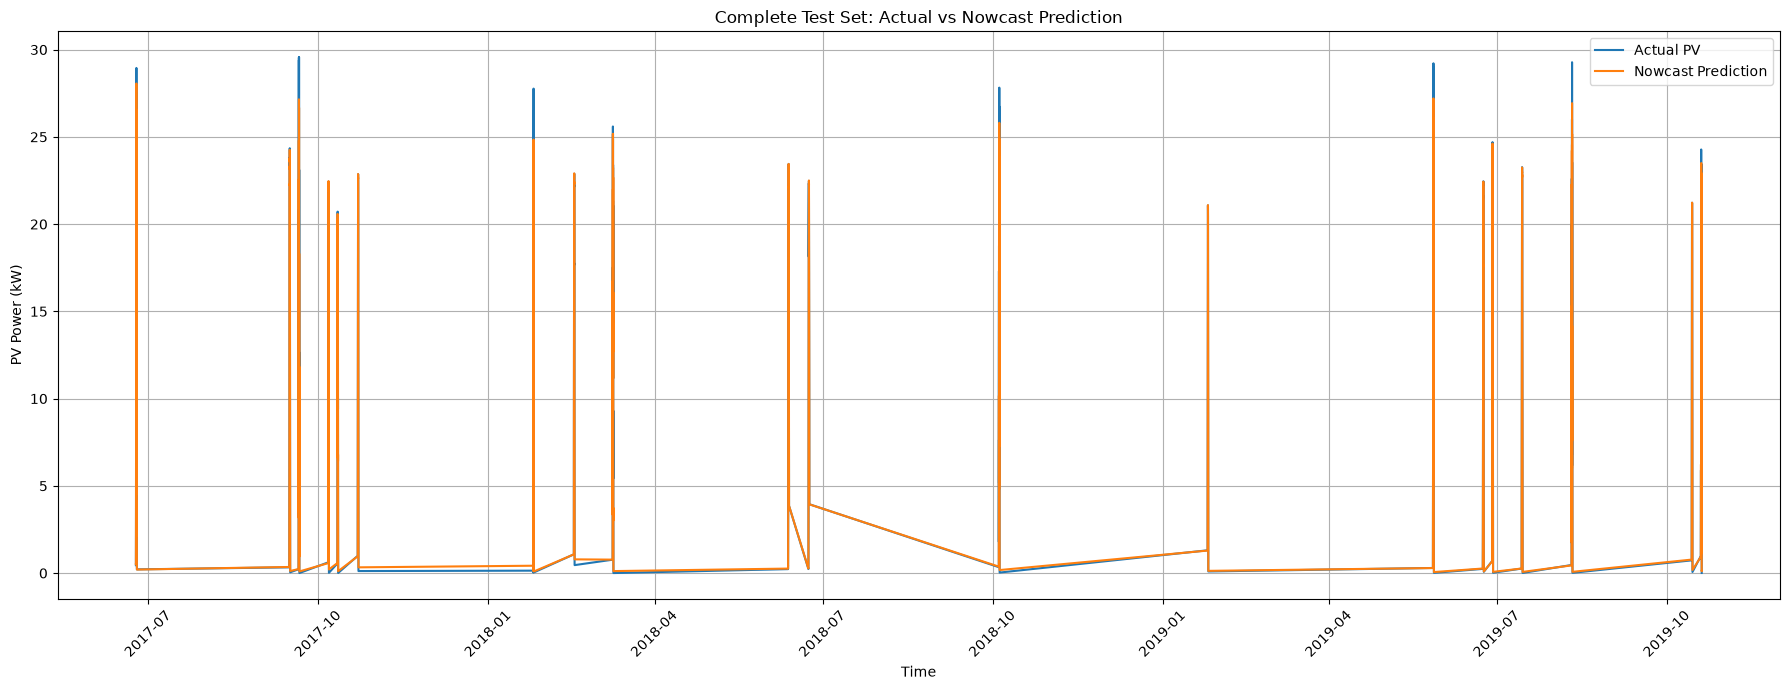

In [14]:
# TEST SET EVALUATION

# Calculate prediction errors
errors = ensemble_predictions - y_test

# RMSE
rmse_overall = np.sqrt(np.mean(np.square(errors)))

# MAE
mae_overall = np.mean(np.abs(errors))

print("COMPLETE TEST SET NOWCAST RESULTS")

print(f"Total Test Sequences: {len(y_test):,}")
print(f"Overall Test RMSE:    {rmse_overall:.3f} kW")
print(f"Overall Test MAE:     {mae_overall:.3f} kW")


# TIME-SERIES PLOT

plt.figure(figsize=(18, 7))

plt.plot(times_test_seq, y_test, label="Actual PV")

plt.plot(times_test_seq, ensemble_predictions, label="Nowcast Prediction")

plt.xlabel("Time")
plt.ylabel("PV Power (kW)")
plt.title("Complete Test Set: Actual vs Nowcast Prediction")

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [15]:
# SUNNY AND CLOUD DATES FROM THE SKIPP'D PAPER

sunny_dates = [
    (2017, 9, 15),
    (2017, 10, 6),
    (2017, 10, 22),
    (2018, 2, 16),
    (2018, 6, 12),
    (2018, 6, 23),
    (2019, 1, 25),
    (2019, 6, 23),
    (2019, 7, 14),
    (2019, 10, 14),
]

cloudy_dates = [
    (2017, 6, 24),
    (2017, 9, 20),
    (2017, 10, 11),
    (2018, 1, 25),
    (2018, 3, 9),
    (2018, 10, 4),
    (2019, 5, 27),
    (2019, 6, 28),
    (2019, 8, 10),
    (2019, 10, 19),
]

sunny_dates_test = [datetime.date(y, m, d) for y, m, d in sunny_dates]

cloudy_dates_test = [datetime.date(y, m, d) for y, m, d in cloudy_dates]

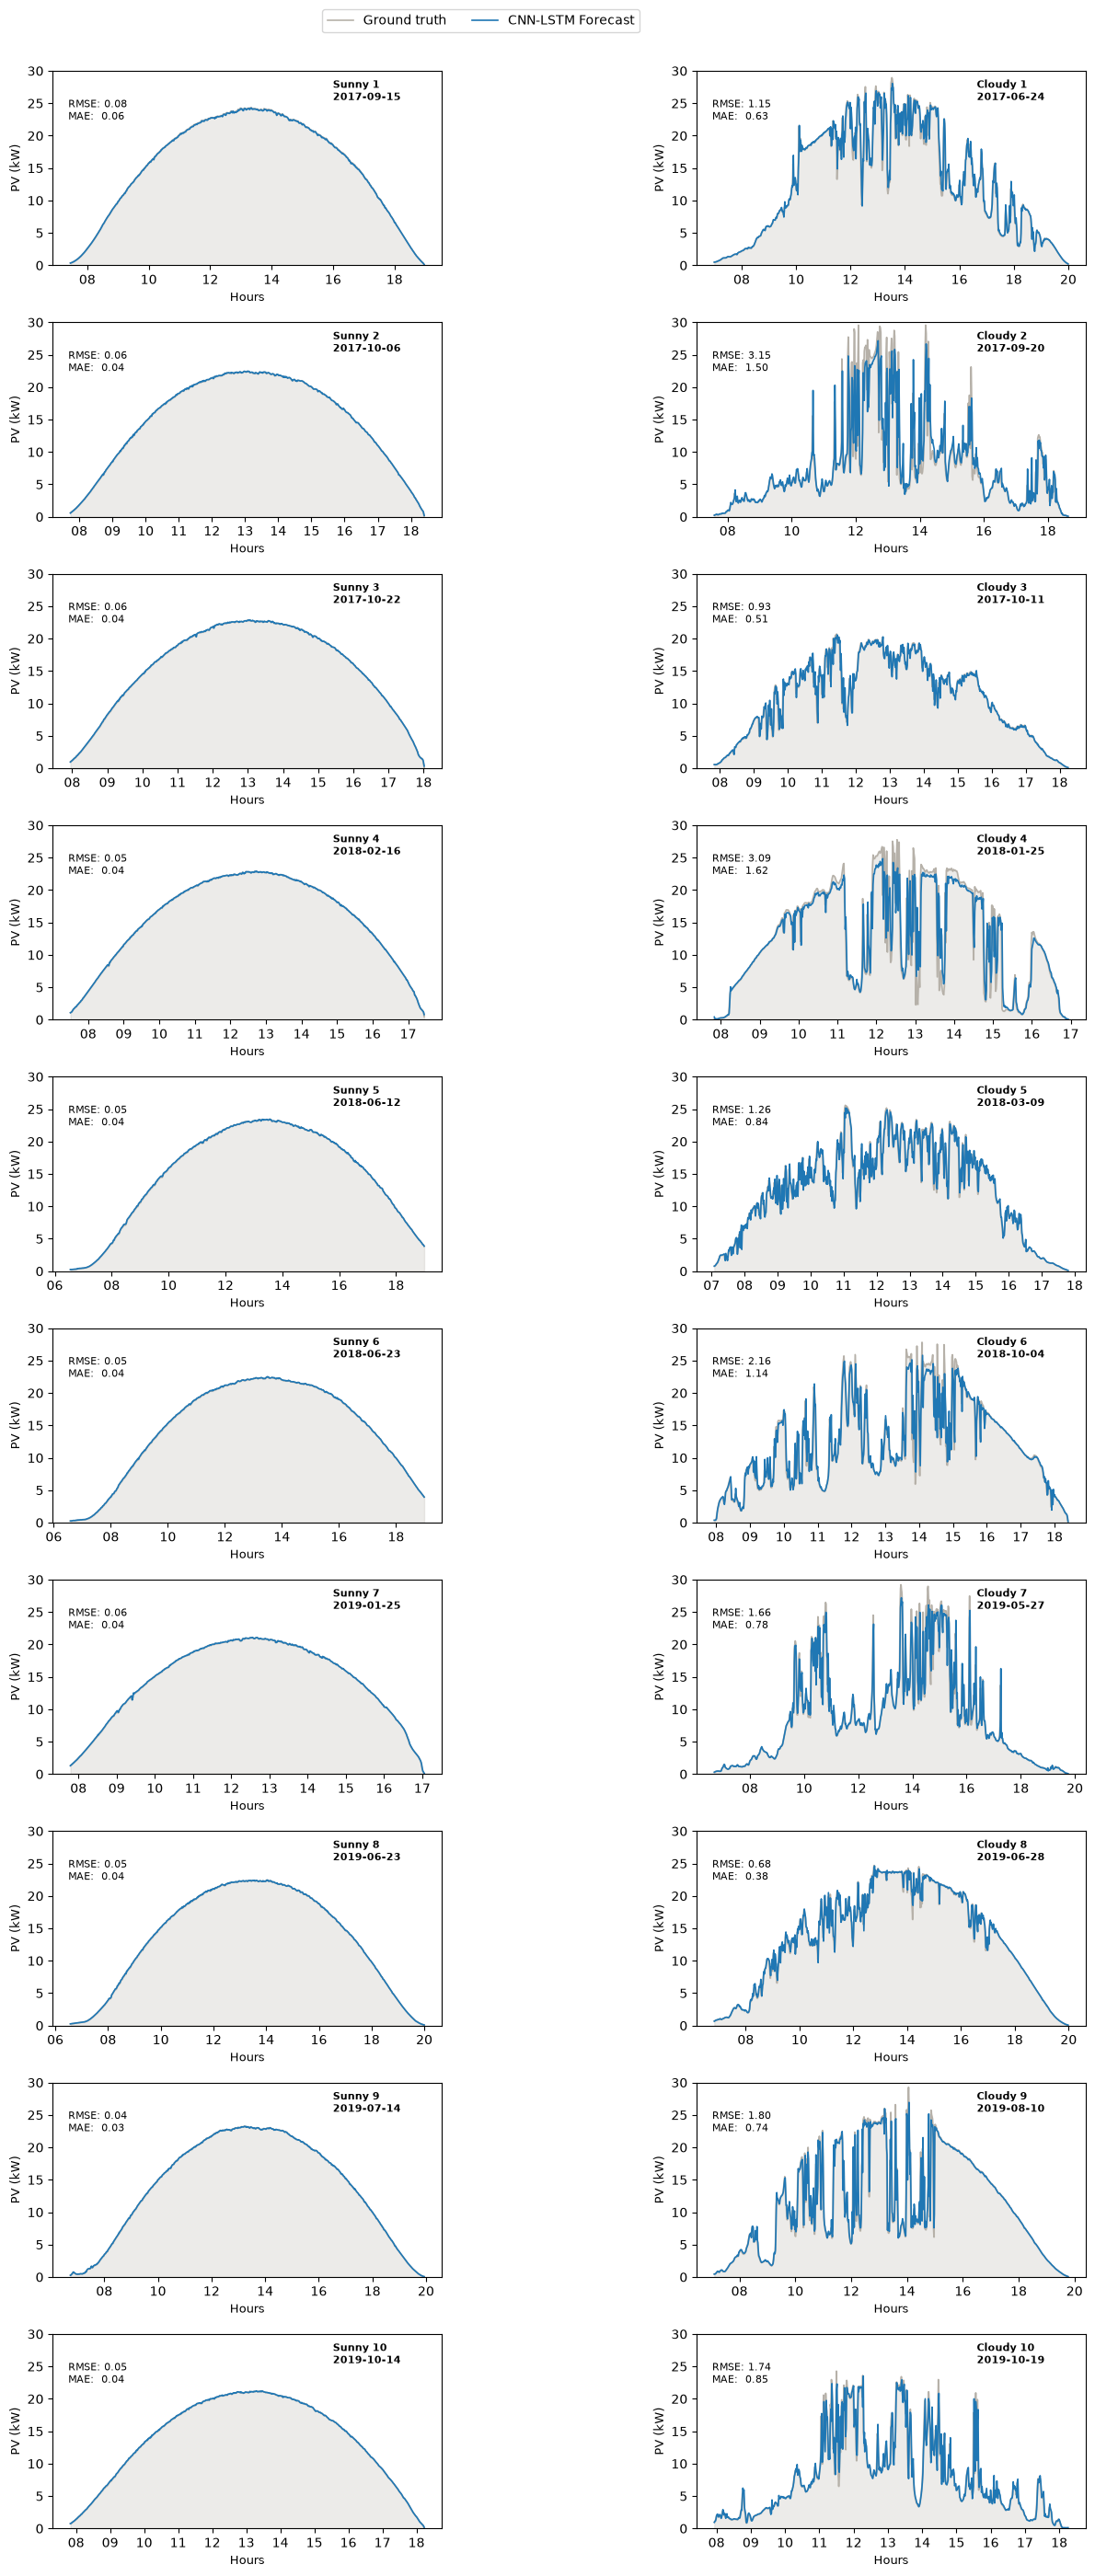

In [16]:
hours_test_seq = np.array(
    [
        (
            t.time()
            if isinstance(t, (datetime.datetime, datetime.time))
            else pd.to_datetime(t).time()
        )
        for t in times_test_seq
    ]
)

fig, axarr = plt.subplots(10, 2, sharex=False, sharey=True, figsize=(12, 28))

xfmt = mdates.DateFormatter("%H")
fmt_date = datetime.date(2000, 1, 1)

COLOR_GT = "#B6B1A9"
COLOR_PRED = "#1f77b4"


# Plot Sunny Days
for i, date in enumerate(sunny_dates_test):
    ax = axarr[i, 0]
    date_mask = dates_test_seq == date

    hours_xaxis = [
        datetime.datetime.combine(fmt_date, h) for h in hours_test_seq[date_mask]
    ]

    y_true_d = y_test[date_mask]
    y_pred_d = ensemble_predictions[date_mask]

    d_rmse = np.sqrt(np.mean(np.square(y_true_d - y_pred_d)))

    d_mae = np.mean(np.abs(y_true_d - y_pred_d))

    ax.plot(
        hours_xaxis,
        y_true_d,
        color=COLOR_GT,
        linewidth=1.2,
        label="Ground truth" if i == 0 else "",
    )

    ax.fill_between(hours_xaxis, 0, y_true_d, color=COLOR_GT, alpha=0.25)

    ax.plot(
        hours_xaxis,
        y_pred_d,
        color=COLOR_PRED,
        linewidth=1.2,
        label="CNN-LSTM Forecast" if i == 0 else "",
    )

    ax.set_ylabel("PV (kW)", fontsize=9)
    ax.set_xlabel("Hours", fontsize=9)
    ax.xaxis.set_major_formatter(xfmt)

    ax.text(
        0.72,
        0.85,
        f"Sunny {i + 1}\n{date}",
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
    )

    ax.text(
        0.04,
        0.75,
        f"RMSE: {d_rmse:.2f}\nMAE:  {d_mae:.2f}",
        transform=ax.transAxes,
        fontsize=8,
    )


# Plot Cloudy Days
for i, date in enumerate(cloudy_dates_test):
    ax = axarr[i, 1]
    date_mask = dates_test_seq == date

    hours_xaxis = [
        datetime.datetime.combine(fmt_date, h) for h in hours_test_seq[date_mask]
    ]

    y_true_d = y_test[date_mask]
    y_pred_d = ensemble_predictions[date_mask]

    d_rmse = np.sqrt(np.mean(np.square(y_true_d - y_pred_d)))

    d_mae = np.mean(np.abs(y_true_d - y_pred_d))

    ax.plot(hours_xaxis, y_true_d, color=COLOR_GT, linewidth=1.2)

    ax.fill_between(hours_xaxis, 0, y_true_d, color=COLOR_GT, alpha=0.25)

    ax.plot(hours_xaxis, y_pred_d, color=COLOR_PRED, linewidth=1.2)

    ax.set_ylabel("PV (kW)", fontsize=9)
    ax.set_xlabel("Hours", fontsize=9)
    ax.tick_params(axis="y", labelleft=True)
    ax.xaxis.set_major_formatter(xfmt)

    ax.text(
        0.72,
        0.85,
        f"Cloudy {i + 1}\n{date}",
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
    )

    ax.text(
        0.04,
        0.75,
        f"RMSE: {d_rmse:.2f}\nMAE:  {d_mae:.2f}",
        transform=ax.transAxes,
        fontsize=8,
    )


axarr[0, 0].set_ylim(0, 30)

axarr[0, 0].legend(bbox_to_anchor=[1.1, 1.35], loc="upper center", ncol=2, frameon=True)

plt.tight_layout()

plt.show()

In [19]:
%load_ext tensorboard

%tensorboard --logdir "model_output/CNN_LSTM_nowcast_2017_2019_data/tensorboard_logs"

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6007 (pid 117405), started 0:00:02 ago. (Use '!kill 117405' to kill it.)